   Rainfall  Temperature  Soil_Moisture   Soil_pH  Nitrogen  Phosphorus  \
0  0.577079     1.528892       0.501549 -0.542526 -1.347283   -0.244281   
1 -0.474170     0.630255      -0.717453  0.331844  0.137897   -1.057842   
2 -0.814329    -0.854449       0.000180  1.206215  0.546834    1.356104   
3 -0.782371     1.528892      -0.451363  0.532949  0.810878    0.144442   
4 -0.803937    -1.225625      -0.226755  0.681592  0.692414    0.871296   

   Irrigation  Crop_Area  Fertilizer  Pesticide  Sunlight  Crop_Diversity  \
0   -1.508541  -2.141981   -1.231144  -1.823204 -1.144160        0.693137   
1    1.423335   2.152128    0.117762   1.444803  1.547982        0.096585   
2    1.848923  -0.028065    0.342579   0.000000  0.471125        0.096585   
3    1.300073   0.383288    1.860098   1.444803  0.201911        2.482794   
4    1.726710   0.305967    1.860098   1.444803  0.201911        0.693137   

   Mechanization  Yield_Variance  
0       0.363784       -1.190426  
1       0.207976

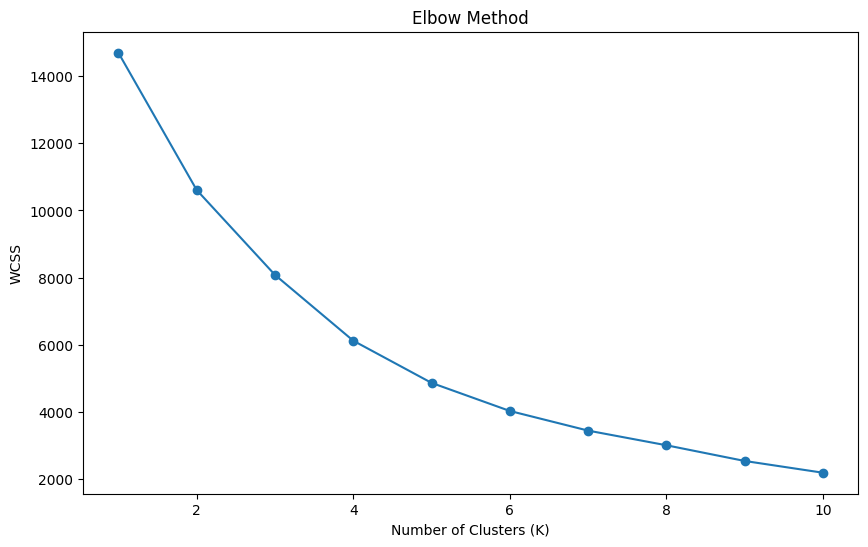

   Rainfall  Temperature  Soil_Moisture   Soil_pH  Nitrogen  Phosphorus  \
0  0.577079     1.528892       0.501549 -0.542526 -1.347283   -0.244281   
1 -0.474170     0.630255      -0.717453  0.331844  0.137897   -1.057842   
2 -0.814329    -0.854449       0.000180  1.206215  0.546834    1.356104   
3 -0.782371     1.528892      -0.451363  0.532949  0.810878    0.144442   
4 -0.803937    -1.225625      -0.226755  0.681592  0.692414    0.871296   

   Irrigation  Crop_Area  Fertilizer  Pesticide  Sunlight  Crop_Diversity  \
0   -1.508541  -2.141981   -1.231144  -1.823204 -1.144160        0.693137   
1    1.423335   2.152128    0.117762   1.444803  1.547982        0.096585   
2    1.848923  -0.028065    0.342579   0.000000  0.471125        0.096585   
3    1.300073   0.383288    1.860098   1.444803  0.201911        2.482794   
4    1.726710   0.305967    1.860098   1.444803  0.201911        0.693137   

   Mechanization  Yield_Variance  Cluster  
0       0.363784       -1.190426        1 

In [3]:
# =========================================
# PHASE 6 : K-MEANS CLUSTERING
# Elbow Method + Model Training
# =========================================

# -----------------------------------------
# Step 1 : Import Required Libraries
# -----------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans


# -----------------------------------------
# Step 2 : Load Final Selected Dataset
# -----------------------------------------

# Load dataset after feature selection
# This dataset contains only important features

final_df = pd.read_csv("final_selected_features_dataset.csv")

print(final_df.head())
print("Dataset Shape:", final_df.shape)


# -----------------------------------------
# Step 3 : Elbow Method
# -----------------------------------------

# Elbow Method helps us find the optimal
# number of clusters (K)

# WCSS = Within Cluster Sum of Squares
# Lower WCSS means tighter clusters

wcss = []

# Try K values from 1 to 10
for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        max_iter=300,
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(final_df)
    
    # inertia_ gives WCSS value
    wcss.append(kmeans.inertia_)


# -----------------------------------------
# Step 4 : Plot Elbow Curve
# -----------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()


# -----------------------------------------
# Step 5 : Apply Final K-Means Model
# -----------------------------------------

# Choose the best K after observing elbow graph
# Example: if elbow appears at K = 4

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

# Train the model
cluster_labels = kmeans.fit_predict(final_df)


# -----------------------------------------
# Step 6 : Add Cluster Labels to Dataset
# -----------------------------------------

# Create new column showing cluster number

final_df["Cluster"] = cluster_labels

print(final_df.head())


# -----------------------------------------
# Step 7 : Count Data Points in Each Cluster
# -----------------------------------------

print("Cluster Distribution:")
print(final_df["Cluster"].value_counts())


# -----------------------------------------
# Step 8 : Save Clustered Dataset
# -----------------------------------------

final_df.to_csv(
    "kmeans_clustered_agriculture_dataset.csv",
    index=False
)

print("K-Means Clustering Completed Successfully ")